# Explore Noise

## Set Up Model and Dataset

In [1]:
import os
import shutil
import tempfile
import time as pytime
from pathlib import Path

import pandas as pd
from cdo import Cdo
from tqdm import tqdm
import json

from neural_transport.inference.plot_results import plot_noise_diagnostics, plot_masking_diagnostics


# neural_transport
from neural_transport.models.wrappers_registry import MODELWRAPPERS
from neural_transport.litmodule import NeuralTransport
from neural_transport.tools.conversion import *
from neural_transport.datasets.grids import (
    LATLON_PROTOTYPE_COORDS,
    VERTICAL_LAYERS_PROTOTYPE_COORDS,
)
from neural_transport.datamodule import CarbonDataModule, CarbonDataset

# plotting
import cartopy.crs as ccrs
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm

import seaborn as sns
import matplotlib.gridspec as gridspec

# numpy
import numpy as np

# torch
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch_harmonics

import xarray as xr

# sklearn
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver

/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/cdo/cdo.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /lib64/libc.so.6: version `GLIBC_2.32' not found (required by /Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_scatter/_version_cuda.so)
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_geometric/typing.py:97: User

In [2]:
torch.set_float32_matmul_precision("high")
pl.seed_everything(42)

Seed set to 42


42

In [3]:
TARGET_VARS = ["co2massmix"]
# Uncomment for conditional Flow Matching
FORCING_VARS_1D = [
    # "flow_time"
]
FORCING_VARS_2D = [
    # "blh",
    # "cell_area",
    # "co2flux_anthro",
    # "co2flux_land",
    # "co2flux_ocean",
    # "orography",
    # "tisr",
]
FORCING_VARS_3D = [
    # "airmass",
    # "gph_bottom",
    # "gph_top",
    # "p_bottom",
    # "p_top",
    # "q",
    # "t",
    # "u",
    # "v",
]
grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

nlev = len(VERTICAL_LAYERS_PROTOTYPE_COORDS[vertical_levels]["level"])

FORCING_VARS = FORCING_VARS_1D + FORCING_VARS_2D + FORCING_VARS_3D
LEN_ALL_TARGET_VARS = nlev * len(TARGET_VARS)
LEN_ALL_FORCING_VARS = len(FORCING_VARS_1D) + len(FORCING_VARS_2D) + nlev * len(FORCING_VARS_3D)
LEN_ALL_VARS = LEN_ALL_TARGET_VARS + LEN_ALL_FORCING_VARS

lat = LATLON_PROTOTYPE_COORDS[grid]["lat"]
lon = LATLON_PROTOTYPE_COORDS[grid]["lon"]

cos_lat = np.cos(np.radians(lat))[:, None, None].repeat(len(lon), axis=1).reshape(-1, 1)
cos_lat = cos_lat / np.mean(cos_lat)

ds_stats = xr.open_zarr(
    f"/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/train/carbontracker_{grid}_{vertical_levels}_{freq}_stats.zarr"
).compute()

inv_std = {
    k: 1
    / (ds_stats[f"{k}_delta"].sel(stats="std").where(lambda x: x > 1e-14, 1).values)
    ** 2
    for k in TARGET_VARS  # CARBOSCOPE_CARBON3D_VARS
}

weights = {k: cos_lat * inv_std[k] for k in inv_std}

LOSS_WEIGHTS = {k: (10 * v / LEN_ALL_TARGET_VARS) for k, v in weights.items()}

METRIC_WEIGHTS = {f"{k}_delta": cos_lat for k in TARGET_VARS}


MODEL_DIMS = {
    "XS": dict(embed_dim=64),
    "S": dict(embed_dim=128),
    "M": dict(embed_dim=256),
    "L": dict(embed_dim=512),
    "XL": dict(embed_dim=1024),
}

MODEL_SIZE = "S"

regulargrid_kwargs = dict( # for RegularGridModel
    input_vars=TARGET_VARS + FORCING_VARS,
    target_vars=TARGET_VARS,
    nlat=len(lat),
    nlon=len(lon),
    predict_delta=False,
    add_surfflux=False,
    dt=60 * 60 * 6,
    massfixer="",
    targshift=True,
)

wrapper_kwargs = dict( # for RegularGridModel (FlowMatching)
    **regulargrid_kwargs,
    model_kwargs=dict( # for FlowMatching
        submodel="unet",
        model_kwargs=dict( # for RegularGridModel (UNet)
            **regulargrid_kwargs,
            model_kwargs=dict( # for UNet
                in_chans=LEN_ALL_VARS + 1, # + 1 for flow_time
                out_chans=LEN_ALL_TARGET_VARS,
                embed_dim=MODEL_DIMS[MODEL_SIZE]["embed_dim"],
                act="leakyrelu",
                norm="batch",
                enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
                dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
                in_interpolation="bilinear",
                out_interpolation="nearest-exact",
                out_clip=None,
            ),
        ),
        return_intermediates=True,
        method="midpoint",  # 'midpoint' or 'euler'
        nlev=nlev,
        step_size=0.1,
    ),
)

In [4]:
# train UNet parameters 2/2

N_GPUS = 1
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_PRED = 32

data_kwargs = dict(
    data_path="/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker",
    dataset="carbontracker",
    grid=grid,
    vertical_levels=vertical_levels,
    freq=freq,
    n_timesteps=1,
    batch_size_train=BATCH_SIZE_TRAIN // N_GPUS,
    batch_size_pred=BATCH_SIZE_PRED,
    num_workers=32 * N_GPUS,
    val_rollout_n_timesteps=None,
    target_vars=["co2massmix"], #, "airmass"
    forcing_vars=[
        # "gph_bottom",
        # "gph_top",
        # "p_bottom",
        # "p_top",
        # "q",
        # "t",
        # "u",
        # "v",
        # "blh",
        # "cell_area",
        # "co2flux_anthro",
        # "co2flux_land",
        # "co2flux_ocean",
        # "orography",
        # "tisr",
    ],
    compute=False,
)

In [5]:
# Load batch from dataset

dset = CarbonDataModule(**data_kwargs)
dset.setup('fit')
dset.val_dataset
dl = dset.train_dataloader()
print(type(dl))
print(len(dl))
batch = next(iter(dl))
batch = {k: v[:, 0,...] if isinstance(v, torch.Tensor) else v for k, v in batch.items() }
print(batch.keys())
print(len(batch))

<class 'torch.utils.data.dataloader.DataLoader'>
388
dict_keys(['airmass_delta_offset', 'airmass_delta_scale', 'airmass_next_offset', 'airmass_next_scale', 'airmass_offset', 'airmass_scale', 'blh_delta_offset', 'blh_delta_scale', 'blh_next_offset', 'blh_next_scale', 'blh_offset', 'blh_scale', 'cell_area_delta_offset', 'cell_area_delta_scale', 'cell_area_next_offset', 'cell_area_next_scale', 'cell_area_offset', 'cell_area_scale', 'co2flux_anthro_delta_offset', 'co2flux_anthro_delta_scale', 'co2flux_anthro_next_offset', 'co2flux_anthro_next_scale', 'co2flux_anthro_offset', 'co2flux_anthro_scale', 'co2flux_land_delta_offset', 'co2flux_land_delta_scale', 'co2flux_land_next_offset', 'co2flux_land_next_scale', 'co2flux_land_offset', 'co2flux_land_scale', 'co2flux_ocean_delta_offset', 'co2flux_ocean_delta_scale', 'co2flux_ocean_next_offset', 'co2flux_ocean_next_scale', 'co2flux_ocean_offset', 'co2flux_ocean_scale', 'co2massmix', 'co2massmix_delta_offset', 'co2massmix_delta_scale', 'co2massmix

In [6]:
flow = MODELWRAPPERS["flowmatching"](**wrapper_kwargs)

generate_kwargs = dict(
    n_samples=100,
    masking=False,
    pattern="random",  # if masking=True: "random", "vertical", "horizontal", "checkerboard", "sattelite",
    obs_fraction=0.2,  # if masking=True: [0, 1]
    noise=None,  # None, "spiral_outward_noise", "spiral_noise", "gaussian_noise", "geodesic_noise", "linear_noise",
    analyze_noise=True,
)

In [7]:
# lit module kwargs

cos_lat = np.cos(np.radians(lat))[:, None, None].repeat(len(lon), axis=1).reshape(-1, 1)
cos_lat = cos_lat / np.mean(cos_lat)

ds_stats = xr.open_zarr(
    f"/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/train/carbontracker_{grid}_{vertical_levels}_{freq}_stats.zarr"
).compute()

inv_std = {
    k: 1
    / (ds_stats[f"{k}_delta"].sel(stats="std").where(lambda x: x > 1e-14, 1).values)
    ** 2
    for k in TARGET_VARS  # CARBOSCOPE_CARBON3D_VARS
}

weights = {k: cos_lat * inv_std[k] for k in inv_std}

LOSS_WEIGHTS = {k: (10 * v / LEN_ALL_TARGET_VARS) for k, v in weights.items()}

METRIC_WEIGHTS = {f"{k}_delta": cos_lat for k in TARGET_VARS}


lit_module_kwargs = dict(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="flowmatching_mse",
    loss_kwargs=dict(),
    metrics=[
        dict(name=m, kwargs=dict(weights=METRIC_WEIGHTS))
        for m in ["rmse", "r2", "nse", "rabsbias", "rrmse"]
    ],
    # + [dict(name="mass_rmsev2", kwargs=dict(molecule=m)) for m in ["co2"]],
    no_grad_step_shedule=None,
    lr=1e-3,
    weight_decay=0.1,
    lr_shedule_kwargs=dict(
        warmup_steps=1000, halfcosine_steps=99000, min_lr=3e-7, max_lr=1.0
    ),
    val_dataloader_names=["singlestep", "rollout"],
    plot_kwargs=dict(
        variables=["co2molemix"],
        layer_idxs=[0, 3, 5, 8],
        n_samples=2,
        dataset="carbontracker",
        grid=grid,
        vertical_levels=vertical_levels,
        max_workers=32,
    ),
)

In [8]:
# trainer_kwargs

data_path_forecast = Path(
    "/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/test/"
)

trainer_kwargs = dict(
    max_steps=10000,
    accelerator="gpu",
    devices=N_GPUS,
    log_every_n_steps=100,
    gradient_clip_val=32,
    precision="bf16-mixed",
    strategy=(
        "auto"
        if N_GPUS == 1
        else pl.strategies.DDPStrategy(find_unused_parameters=False)
    ), # profiler="simple", fast_dev_run=True,
    # overfit_batches=10, # for debugging only!!
)

In [9]:
litmodule = NeuralTransport(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="flowmatching_mse",
    loss_kwargs=dict(),
    metrics=[dict(name="rmse", kwargs=dict(weights=METRIC_WEIGHTS))],
)

In [10]:
# checkpoint path

# best
best_ckpt_path = "/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20251006_unet_targshift_dev/singlestep/checkpoints/best.ckpt"

# last
last_ckpt_path = "/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20251006_unet_targshift_dev/singlestep/checkpoints/last.ckpt"

In [11]:
transport_model = NeuralTransport.load_from_checkpoint(last_ckpt_path, map_location="cpu")
transport_model.eval()

NeuralTransport(
  (model): FlowMatching(
    (submodel): UNet(
      (enc_stages): ModuleList(
        (0): Sequential(
          (0): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(11, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1-3): 3 x Sequential(
          (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (1): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (2): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1

In [12]:
flow_model = transport_model.model

In [13]:
dl_val = dset.val_dataloader()
batch_val = next(iter(dl_val))
batch_val = {k: v.squeeze(1) if isinstance(v, torch.Tensor) else v for k, v in batch_val.items()}

In [14]:
with torch.no_grad():
    output = flow_model(batch_val)

In [15]:
target = batch_val["co2massmix"][0].cpu().numpy()
pred_trajectory = output["trajectory"][0].cpu().numpy() # [B N T]
pred = output["co2massmix"][0].cpu().numpy()

In [16]:
def load_dataset(data_path, data_kwargs):

    dataset = CarbonDataset(
        data_path=data_path,
        dataset=data_kwargs["dataset"],
        grid=data_kwargs["grid"],
        vertical_levels=data_kwargs["vertical_levels"],
        freq=data_kwargs["freq"],
        n_timesteps=1,
        target_vars=data_kwargs["target_vars"],
        forcing_vars=data_kwargs["forcing_vars"],
        load_obspack=True,
        new_zarr=True,
    )

    return dataset

data_path_forecast = Path(
    "/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/test/"
)

dataset = load_dataset(data_path_forecast, data_kwargs) # {k: [T, N, C]}

## Generate Samples

In [17]:
def get_zarrpath_obspath(out_path, rollout, freq, zarr_filename=None, zero_surfflux=False):
    if zarr_filename is None:
        zarr_filename = (
            f"co2_pred_rollout_{freq}.zarr" if rollout else "co2_pred_singlestep.zarr"
        )
    if zero_surfflux:
        zarr_filename = zarr_filename.replace("co2_pred", "co2_pred_zeroflux")

    out_path = Path(out_path)
    out_path.mkdir(exist_ok=True, parents=True)
    zarrpath = out_path / zarr_filename

    obspath = out_path / f"obs_{zarr_filename}"

    return zarrpath, obspath


def remap_with_cdo(dataset, prototype_zarr, ds):
    cdo = Cdo()
    prototype_zarr.lat.attrs = {
        "long_name": "latitude",
        "units": "degrees_north",
        "standard_name": "latitude",
    }
    prototype_zarr.lon.attrs = {
        "long_name": "longitude",
        "units": "degrees_east",
        "standard_name": "longitude",
    }

    ds["clon_vertices"] = dataset.grid_ds.clon_vertices
    ds["clat_vertices"] = dataset.grid_ds.clat_vertices
    ds["clon"] = dataset.grid_ds.clon
    ds["clat"] = dataset.grid_ds.clat
    ds["co2massmix"].attrs = {"CDI_grid_type": "unstructured"}
    ds["co2density"].attrs = {"CDI_grid_type": "unstructured"}
    ds["time"].attrs = {"standard_name": "time"}
    ds["height"].attrs = {"standard_name": "air_pressure"}

    grid_temp_file = tempfile.NamedTemporaryFile(
        delete=True, prefix="grid_temp_file_", dir=tempfile.gettempdir()
    )
    prototype_zarr.to_netcdf(grid_temp_file.name)

    ds_temp_file = tempfile.NamedTemporaryFile(
        delete=True, prefix="ds_temp_file_", dir=tempfile.gettempdir()
    )
    ds.transpose("time", "height", "cell", "nv").to_netcdf(ds_temp_file.name)

    ds_remap = cdo.remapcon(
        grid_temp_file.name, input=ds_temp_file.name, returnXDataset=True
    )

    grid_temp_file.close()
    ds_temp_file.close()

    cdo.cleanTempDir()
    return ds_remap


def generate_noise(batch, n_samples=10, noise=None):

    all_levels = batch["co2massmix"] # [T N C]
    all_levels = all_levels.unsqueeze(0) # [B T N C]

    if noise is None:
        return [torch.randn_like(all_levels) for _ in range(n_samples)]

    elif noise == "spiral_outward_noise":
        # Step 1: pick a reference noise vector
        x0 = torch.randn_like(all_levels)
        # Step 2: pick a direction vector (independent random noise)
        v = torch.randn_like(all_levels)
        # Step 3: create spiral path
        angles = torch.linspace(0, 4*torch.pi, n_samples)

        spiral_noises = []
        for a in angles:
            # Step 4: rotate between x0 and v
            x_init = torch.cos(a) * x0 + torch.sin(a) * v
            # Step 5: scale radius outward
            r = 1.0 + 0.2 * (a / angles[-1])  # gradually increase radius
            x_init_scaled = r * x_init
            spiral_noises.append(x_init_scaled)
        return spiral_noises

    elif noise == "spiral_noise":
        x0 = torch.randn_like(all_levels)
        v = torch.randn_like(all_levels)
        angles = torch.linspace(0, 4*torch.pi, n_samples)

        spiral_noises = []
        for a in angles:
            x_init = torch.cos(a) * x0 + torch.sin(a) * v
            spiral_noises.append(x_init)
        return spiral_noises

    elif noise == "geodesic_noise":
        x0 = torch.randn_like(all_levels)
        v = torch.randn_like(all_levels)
        alphas = torch.linspace(0, 1, n_samples)
        return [torch.sqrt((1 - alpha)) * x0 + torch.sqrt(alpha) * v for alpha in alphas]

    elif noise == "linear_noise":
        x0 = torch.randn_like(all_levels)
        v = torch.randn_like(all_levels)
        alphas = torch.linspace(0, 1, n_samples)
        return [(1 - alpha) * x0 + alpha * v for alpha in alphas]

    elif noise == "antipodal_orthogonal_noise":
        x0 = torch.randn_like(all_levels)
        n_dirs = n_samples // 2  # each direction will yield a +v and -v pair
        # Start with random Gaussian directions
        dirs = [torch.randn_like(x0).flatten() for _ in range(n_dirs)]
        # Orthogonalize via Gram–Schmidt
        orth_dirs = []
        for v in dirs:
            for u in orth_dirs:
                v -= (v @ u) / (u @ u) * u
            orth_dirs.append(v)

        # Convert back to tensor shape and include antipodal pairs
        orth_dirs = [v.reshape_as(x0) for v in orth_dirs]
        all_noises = []
        for v in orth_dirs:
            all_noises.append(v)
            all_noises.append(-v)

        # If we have fewer than n_samples due to rounding
        if len(all_noises) < n_samples:
            all_noises.append(torch.randn_like(x0))

        return all_noises[:n_samples]

    else:
        raise ValueError(f"Unknown noise type: {noise}")


def create_mask(batch, target_var="co2massmix", obs_fraction=0.1, pattern="random", nlat=32, nlon=64):
    """
    Create a random observation mask for the input batch.
    Args:
        batch: dict of tensors, each of shape [B T N C]
        target_var: the variable to create the mask for
        obs_fraction: fraction of points to keep as observations
        pattern: "random", "vertical", "horizontal", "checkerboard", "satellite"
    """
    device = batch[target_var].device
    B, T, N, C = batch[target_var].shape

    obs_mask = torch.zeros((B, T, N, C), dtype=torch.bool, device=device)
    obs_values = torch.full_like(batch[target_var], float('nan'), device=device)

    for t in range(T):
        if pattern == "random":
            num_obs = int(obs_fraction * N)
            obs_indices = torch.randperm(N, device=device)[:num_obs]

        elif pattern == "vertical":
            # keep a fixed fraction of longitude columns
            num_cols = max(1, int(obs_fraction * nlon))
            cols = torch.arange(0, nlon, nlon // num_cols, device=device)
            grid = torch.arange(N, device=device).reshape(nlat, nlon)
            obs_indices = grid[:, cols].reshape(-1)

        elif pattern == "horizontal":
            # keep a fixed fraction of latitude rows
            num_rows = max(1, int(obs_fraction * nlat))
            rows = torch.arange(0, nlat, nlat // num_rows, device=device)
            grid = torch.arange(N, device=device).reshape(nlat, nlon)
            obs_indices = grid[rows, :].reshape(-1)

        elif pattern == "checkerboard":
            grid = torch.arange(N, device=device).reshape(nlat, nlon)
            mask2d = (torch.arange(nlat, device=device)[:, None] +
                      torch.arange(nlon, device=device)[None, :]) % 2 == 0
            obs_indices = grid[mask2d].reshape(-1)

        elif pattern == "satellite":
            # grid = [nlat, nlon]
            grid = torch.arange(N, device=device).reshape(nlat, nlon)
            # choose swath width (fraction of nlon)
            swath_width = max(1, int(obs_fraction * nlon / 8))
            # tilt angle in radians (small tilt)
            tilt = -5 * np.pi / 180.0  
            cols = []
            for i in range(0, nlon, swath_width * 8):  # spacing between swaths
                for w in range(swath_width):
                    col_idx = i + w
                    if col_idx < nlon:
                        # apply tilt shift proportional to latitude
                        lat_offsets = ((torch.arange(nlat, device=device) * np.tan(tilt)).long()) % nlon
                        col_with_tilt = (col_idx + lat_offsets) % nlon
                        cols.append(col_with_tilt.unsqueeze(0))
            # stack and mask
            cols = torch.cat(cols, dim=0)  # shape [n_swath, nlat]
            obs_indices = grid[torch.arange(nlat).unsqueeze(0), cols].reshape(-1)

        else:
            raise ValueError(f"Unknown mask pattern: {pattern}")

        # fill mask + values
        obs_mask[:, t, obs_indices, :] = True
        obs_values[:, t, obs_indices, :] = batch[target_var][:, t, obs_indices, :]

    return obs_mask, obs_values  # [B T N C] each


def iterative_generate(
    model,
    dataset,
    outpath,
    rollout=False,
    device="cuda",
    zarr_filename=None,
    freq=None,
    zero_surfflux=False,
    remap=False,
    target_vars_3d=[],
    target_vars_2d=[],
    save_obs=True,
    **generate_kwargs,
):
    n_samples = generate_kwargs.get("n_samples", 10)
    masking = generate_kwargs.get("masking", False)
    pattern = generate_kwargs.get("pattern", "vertical")
    analyze_masking = generate_kwargs.get("analyze_masking", False)
    obs_fraction = generate_kwargs.get("obs_fraction", 0.2)
    noise = generate_kwargs.get("noise", None)
    analyze_noise = generate_kwargs.get("analyze_noise", False)

    nlat, nlon = model.model.in_nlat, model.model.in_nlon

    zarrpath, obspath = get_zarrpath_obspath(outpath, rollout, freq, zarr_filename, zero_surfflux = zero_surfflux)

    prototype_zarr = dataset.create_prototype_zarr(
        zarrpath,
        target_vars_3d=target_vars_3d,
        target_vars_2d=target_vars_2d,
        grid="default" if remap else None,
    )

    model = model.eval().to(device)
    model.return_intermediates = True

    dss = []
    obss = []

    # Noise
    noise_list = generate_noise(dataset[0], n_samples=n_samples, noise=noise)
    if analyze_noise and noise is not None:
        if noise in ["spiral_noise", "spiral_outward_noise"]:
            angles = torch.linspace(0, 4*torch.pi, n_samples) # thetas
            param_name = "$\\theta$"
        elif noise in ["geodesic_noise", "linear_noise"]:
            angles = torch.linspace(0, 1, n_samples)  # alphas
            param_name = "$\\alpha$"
        elif noise == "antipodal_orthogonal_noise":
            labels = []
            for i in range(n_samples // 2):
                labels += [f"{i+1}a", f"{i+1}b"]
            if n_samples % 2 == 1:
                labels.append(f"{(n_samples // 2) + 1}a")
            angles = labels
            param_name = "Index pair"
        else:
            angles = torch.arange(n_samples)  # index
            param_name = "Index"
        plot_noise_diagnostics(noise_list, angles, str(outpath).replace("preds", "plots"),
                               label=param_name, imgformats=["png"])

    base_batch = {k: v.unsqueeze(0).to(device) for k, v in dataset[0].items()} # condition on the first timestep

    if masking:
        target_var = target_vars_3d[0]
        obs_mask, obs_values = create_mask(base_batch, target_var=target_var, obs_fraction=obs_fraction, pattern=pattern, nlat=nlat, nlon=nlon)
        base_batch["obs_mask"] = obs_mask
        obs_values_normed = model.model.normalize_observations(obs_values, base_batch, target_var=target_var)
        base_batch["obs_values"] = obs_values_normed

    for i in range(n_samples):
        # base_batch = {k: v.unsqueeze(0).to(device) for k, v in dataset[i].items()} # condition on different timesteps

        # if masking:
        #     target_var = target_vars_3d[0]
        #     obs_mask, obs_values = create_mask(base_batch, target_var=target_var, obs_fraction=obs_fraction, pattern=pattern, nlat=nlat, nlon=nlon)
        #     base_batch["obs_mask"] = obs_mask
        #     obs_values_normed = model.model.normalize_observations(obs_values, base_batch, target_var=target_var)
        #     base_batch["obs_values"] = obs_values_normed
        batch = {k: v.clone() for k, v in base_batch.items()}
        batch["noise"] = noise_list[i].to(device)

        if zero_surfflux:
            for var in ["co2flux_anthro", "co2flux_land", "co2flux_ocean"]:
                batch[var] = torch.zeros_like(batch[var])

        with torch.no_grad():
            preds = model(batch)
            traj = preds["trajectory"]

        preds_fixed = {}
        for k, v in preds.items():
            if isinstance(v, list):
                v = v[0]
            preds_fixed[k] = v

        if save_obs:
            preds_fixed["gph_bottom"] = batch["gph_bottom"]
            preds_fixed["gph_top"] = batch["gph_top"]

        ds = xr.Dataset(
            {k: dataset.tensor_to_xarray(pred) for k, pred in preds_fixed.items()}
        )

        # ds = ds.assign_coords(
        #     time=prototype_zarr.time[:traj.shape[1]],
        #     sample=("sample", [i]),
        # )
        ds = ds.assign_coords(
            time=("time", prototype_zarr.time[:traj.shape[1]].values if traj.ndim > 0 else [0]),
            sample=("sample", [i]),
        )
        print(ds.dims)
        
        if remap:
            ds = remap_with_cdo(dataset, prototype_zarr.isel(time=0), ds)

        if save_obs:
            obs = dataset.readout_stations(ds, grid="default" if remap else None)
            ds = ds.drop_vars(["gph_bottom", "gph_top"])
            obss.append(obs)

        dss.append(ds)

    ### !!! Caution: need to fix this properly!!!
    def is_bad_sample(arr, thresh=1e6):
        return np.isnan(arr).any() or np.isinf(arr).any() or np.nanmax(np.abs(arr)) > thresh

    good_dss = []
    for i, ds in enumerate(dss):
        if is_bad_sample(ds["co2massmix"].values):
            print(f"Skipping bad sample {i}")
            continue
        good_dss.append(ds)

    ds_all = xr.concat(good_dss, dim="sample")
    ### !!!

    if save_obs:
        obs_all = xr.concat(obss, dim="sample").fillna({"obs_filename": ""})
        obs_all.to_zarr(obspath, mode="w")
        ds_all = ds_all.fillna({"obs_filename": ""})

    ds_all.to_zarr(zarrpath, mode="w")

    if analyze_masking and masking:
        plot_masking_diagnostics(batch, ds_all, str(outpath).replace("preds", "plots"),
                                 varnames=target_vars_3d, nlat=nlat, nlon=nlon,
                                 imgformats=["png"])
        
    base_batch["noise"] = noise_list
    
    return ds_all, base_batch


In [93]:
generate_kwargs = dict(
    n_samples=100,  # 32
    masking=False,
    pattern="vertical",  # if masking=True: "random" (default), "vertical", "horizontal", "checkerboard", "satellite", "test"
    obs_fraction=0.3,  # if masking=True: [0,1]
    noise="spiral_noise",  # None (default), "spiral_outward_noise", "spiral_noise", "geodesic_noise", "linear_noise", "antipodal_orthogonal_noise",
    analyze_noise=True,
    avg_over_levels=True,
)


outpath = Path("test_preds")
ds_all, base_batch = iterative_generate(
    transport_model,
    dataset,
    outpath=outpath,
    rollout=False,
    device="cuda",
    zarr_filename=None,
    freq=None,
    zero_surfflux=False,
    remap=False,
    target_vars_3d=["co2massmix"],
    target_vars_2d=[],
    save_obs=False,   # True only possible if "gph_bottom", "gph_top" are in batch
    **generate_kwargs,
)

FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAc

In [19]:
target_path = (
        data_path_forecast
        / f"{data_kwargs['dataset']}_{data_kwargs['grid']}_{data_kwargs['vertical_levels']}_{data_kwargs['freq']}.zarr"
    )

preds_path = "/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20251006_unet_targshift_dev/singlestep/preds/ckpt=best_massfixer=default/co2_pred_rollout_QS.zarr"

In [20]:
targ = xr.open_zarr(target_path)
co2targ = xr.merge(
    [
        targ["variables_3d"].to_dataset("vari_3d"),
        targ["variables_2d"].to_dataset("vari_2d"),
    ]
)
co2pred = xr.open_zarr(preds_path)

co2targ = co2targ.isel(time=slice(1, None))
co2pred = co2pred.isel(time=slice(1, None))

co2targ["co2massmix"].dims, co2pred["co2massmix"].dims

(('time', 'level', 'lat', 'lon'), ('sample', 'lat', 'lon', 'level'))

In [21]:
ds_all["trajectory"].dims

('sample', 'time', 'lat', 'lon', 'level')

## Explore Noise

In [22]:
def noise_flatten(z):
    """
    z: torch.Tensor shape [B, T, N, C] or [T, N, C] or similar
    returns flattened numpy 1D vector
    """
    if isinstance(z, list):
        z = torch.stack(z, dim=0)
    arr = z.detach().cpu().numpy()
    return arr.reshape(arr.shape[0], -1) if arr.ndim > 1 else arr.reshape(-1)


def extract_features_from_ds(ds, region_masks=None):
    """
    ds: xarray.Dataset with variable 'co2massmix' dims [sample, lat, lon, level]
    Returns pandas.DataFrame with computed features per sample.

    region_masks: dict(name -> boolean mask numpy array of shape [level]) to compute regional integrals.
    """
    co2 = ds["co2massmix"]  # shape: (sample, lat, lon, level)

    # Average over vertical levels
    co2_mean = co2.mean(dim="level")  # -> (sample, lat, lon)

    df = pd.DataFrame(index=co2_mean["sample"].values)

    # === Global summary statistics ===
    df["global_mean"] = co2_mean.mean(dim=("lat", "lon")).values
    df["global_std"] = co2_mean.std(dim=("lat", "lon")).values
    df["global_max"] = co2_mean.max(dim=("lat", "lon")).values
    df["global_min"] = co2_mean.min(dim=("lat", "lon")).values

    # === Latitudinal gradients ===
    lat = co2_mean["lat"].values
    north_mask = lat > 0
    south_mask = lat < 0

    # north/south means (averaged over lon)
    north_mean = co2_mean.sel(lat=lat[north_mask]).mean(dim=("lat", "lon")).values
    south_mean = co2_mean.sel(lat=lat[south_mask]).mean(dim=("lat", "lon")).values
    df["north_mean"] = north_mean
    df["south_mean"] = south_mean
    df["north_minus_south"] = north_mean - south_mean

    # === Optional: region masks ===
    if region_masks is not None:
        for name, mask in region_masks.items():
            mask = np.asarray(mask)
            if mask.shape != co2_mean.isel(sample=0).shape:
                raise ValueError(
                    f"Region mask '{name}' shape {mask.shape} != field shape {co2_mean.isel(sample=0).shape}"
                )
            masked = co2_mean.where(mask)
            df[f"reg_{name}_mean"] = masked.mean(dim=("lat", "lon")).values

    return df


In [23]:
def to_serializable(obj):
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return str(obj)

In [24]:
def analyze_noise_feature_relationship(noise_list, ds_all, outdir, region_masks=None, n_components=2):
    """
    noise_list: list of torch tensors shape [B=1, T, N, C]
    ds_all: xarray.Dataset produced by iterative_generate (sample dim must match len(noise_list))
    outdir: directory string to save plots
    """
    os.makedirs(outdir, exist_ok=True)

    Z = noise_flatten(torch.stack(noise_list, dim=0))  # shape (n_samples, d)
    features = extract_features_from_ds(ds_all, region_masks=region_masks)

    # PCA embed
    pca = PCA(n_components=n_components)
    Z_pca = pca.fit_transform(Z)

    # plot PCA colored by each feature
    for col in features.columns:
        plt.figure(figsize=(6, 5))
        plt.scatter(Z_pca[:, 0], Z_pca[:, 1], c=features[col].values, s=40)
        plt.colorbar(label=col)
        plt.xlabel("PCA1")
        plt.ylabel("PCA2")
        plt.title(f"PCA of noise colored by {col}")
        plt.savefig(os.path.join(outdir, f"pca_colored_{col}.png"), dpi=200)
        plt.close()

    # Linear probe (ridge) for each feature
    results = {}
    X_train, X_test, y_train_full, y_test_full = train_test_split(Z, features.values, test_size=0.2, random_state=0)
    for i, col in enumerate(features.columns):
        y_train = y_train_full[:, i]
        y_test = y_test_full[:, i]
        model = Ridge(alpha=1.0).fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        results[col] = {"r2": r2, "coef_norm": np.linalg.norm(model.coef_)}
    # write results
    with open(os.path.join(outdir, "ridge_results.json"), "w") as f:
        json.dump(results, f, indent=2, default=to_serializable)
    return {"pca": pca, "results": results, "features": features}


In [60]:
def test_linear_mixing(
    model,
    dataset,
    base_batch,
    z_a,
    z_b,
    alphas=np.linspace(0, 1, 10),
    device="cuda",
    save_outdir=None,
    target_var="co2massmix",
):
    """
    Interpolate between two noise vectors z_a, z_b and generate outputs.
    
    Args:
        model: trained transport model
        dataset: dataset object with .tensor_to_xarray
        base_batch: dict (from iterative_generate)
        z_a, z_b: torch.Tensor noise vectors
        alphas: list or np.array of interpolation coefficients
        device: computation device
        save_outdir: optional folder to save zarr files
        target_var: variable to extract for analysis (default: "co2massmix")
    Returns:
        results: dict with alpha -> (feature_value, dataset)
    """
    model = model.eval().to(device)
    results = {}

    for a in alphas:
        # linearly mix between the two noise vectors
        z = np.sqrt((1 - a)) * z_a + np.sqrt(a) * z_b
        if z.ndim == 4:  # [B, T, N, C]
            z = z.squeeze(1)  # [B, N, C]

        # create fresh batch and inject mixed noise
        batch = {k: (v.clone() if torch.is_tensor(v) else v) for k, v in base_batch.items()}
        batch["noise"] = z.unsqueeze(0).to(device)  # ensure correct shape

        with torch.no_grad():
            preds = model(batch)
            traj = preds["trajectory"]

        preds_fixed = {}
        for k, v in preds.items():
            if isinstance(v, list):
                v = v[0]
            preds_fixed[k] = v

        ds = xr.Dataset({k: dataset.tensor_to_xarray(pred) for k, pred in preds_fixed.items()})
        ds = ds.assign_coords(sample=("sample", [float(a)]))

        # Simple feature: global mean of target variable
        arr = ds[target_var].values
        feat = np.nanmean(arr)

        results[float(a)] = {"feature": feat, "dataset": ds}

        # optional saving
        if save_outdir is not None:
            path = Path(save_outdir) / f"mix_{a:.3f}.zarr"
            ds.to_zarr(path, mode="w")

    return results

In [ ]:
def optimize_noise_for_feature(model, base_batch, feature_fn, z0=None, lr=1e-2, steps=200, device="cuda", clamp=None):
    """
    Gradient ascent in noise space to maximize a differentiable feature function.

    Args:
        model: your trained model (e.g. FlowMatching or NeuralTransport)
        base_batch: reference batch (dict) like in iterative_generate
        feature_fn: callable taking preds (dict of tensors) -> scalar torch tensor
        z0: optional initial noise tensor, else random
        lr: learning rate for Adam
        steps: number of optimization steps
        device: "cuda" or "cpu"
        clamp: optional tuple (min, max) to clamp noise after each step

    Returns:
        z_opt: optimized noise tensor (detached)
        history: list of feature values over steps
    """
    model = model.eval().to(device)

    # Initialize noise
    if z0 is None:
        z = torch.randn_like(base_batch["noise"][0], device=device, requires_grad=True)
    else:
        z = z0.to(device).detach().clone().requires_grad_(True)

    opt = torch.optim.Adam([z], lr=lr)
    history = []

    for i in range(steps):
        opt.zero_grad()

        # Clone batch and insert current noise
        batch = {k: (v.clone().to(device) if torch.is_tensor(v) else v)
                 for k, v in base_batch.items()}
        batch["noise"] = z

        # Forward pass
        preds = model(batch)  # preds is a dict, e.g. {"trajectory": tensor, "co2massmix": tensor, ...}

        # Evaluate differentiable feature
        feat = feature_fn(preds)  # must return a scalar tensor
        loss = -feat  # we maximize feat

        # Backprop and update
        loss.backward()
        opt.step()

        if clamp is not None:
            with torch.no_grad():
                z.clamp_(clamp[0], clamp[1])

        # Record current value
        history.append(feat.detach().item())

        if (i + 1) % 20 == 0:
            print(f"[{i+1:03d}/{steps}] feature = {history[-1]:.5f}")

    return z.detach(), history


In [158]:
def feature_fn_global_mean(ds):
    """
    Compute global mean CO₂ from xarray.DataArray or Dataset.
    If ds is a DataArray, just take mean over all dims.
    """
    if isinstance(ds, xr.DataArray):
        return ds.mean()
    elif isinstance(ds, xr.Dataset):
        var_name = list(ds.data_vars)[0]
        return ds[var_name].mean()
    else:
        raise ValueError("ds must be xarray DataArray or Dataset")


In [94]:
outdir = Path("/Net/Groups/BGI/work_5/CO2_diffusion/neural_transport/neural_transport/flowmatching_dev/test_plots/")
res = analyze_noise_feature_relationship(base_batch["noise"], ds_all, str(outdir))

In [29]:
# Region masks

lat = ds_all["lat"].values
lon = ds_all["lon"].values

region_masks = {
    "tropics": np.outer((np.abs(lat) < 23), np.ones_like(lon)),
    "northern_extratropics": np.outer((lat > 30), np.ones_like(lon)),
    "southern_extratropics": np.outer((lat < -30), np.ones_like(lon)),
    "Europe": np.outer((lat > 35) & (lat < 70), (lon > -10) & (lon < 40)),
    "North_America": np.outer((lat > 15) & (lat < 70), (lon > -170) & (lon < -50)),
}

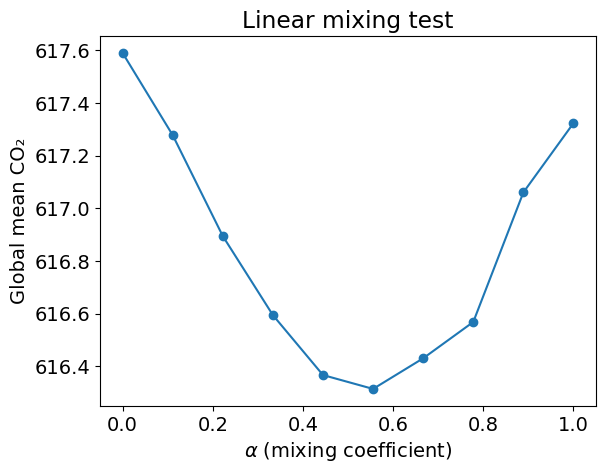

In [126]:
res = test_linear_mixing(
    transport_model,
    dataset,
    base_batch,
    z_a=base_batch["noise"][0],
    z_b=base_batch["noise"][29],
    alphas=np.linspace(0, 1, 10),
    device="cuda",
    save_outdir=outdir,
)

alphas = sorted(res.keys())
features = [res[a]["feature"] for a in alphas]

plt.plot(alphas, features, "-o")
plt.xlabel("$\\alpha$ (mixing coefficient)")
plt.ylabel("Global mean CO₂")
plt.title("Linear mixing test")
plt.savefig(outdir / "linear_mixing_global_mean_co2.png", dpi=200)
plt.show()

In [71]:
# z_opt, hist = optimize_noise_for_feature(
#     model=transport_model,
#     base_batch=base_batch,
#     feature_fn=feature_fn_global_mean,
#     z0=base_batch['noise'][0],
#     lr=5e-3,
#     steps=100,
#     device="cuda",
# )

# plt.plot(hist)
# plt.xlabel("Step")
# plt.ylabel("Global mean CO₂")
# plt.title("Optimizing noise to maximize CO₂")
# plt.savefig(outdir / "optimize_noise_global_mean_co2.png", dpi=200)
# plt.show()


In [70]:
# base_batch["noise"] = z_opt
# with torch.no_grad():
#     preds_opt = transport_model(base_batch)

# # visualize mean map at first time step and mid level
# co2_opt = preds_opt["co2massmix"][0, 0]  # e.g. [lat, lon, level]
# plt.imshow(co2_opt[..., co2_opt.shape[-1]//2].cpu())
# plt.title("CO₂ field for optimized noise")
# plt.colorbar(label="CO₂ mass mixing ratio")

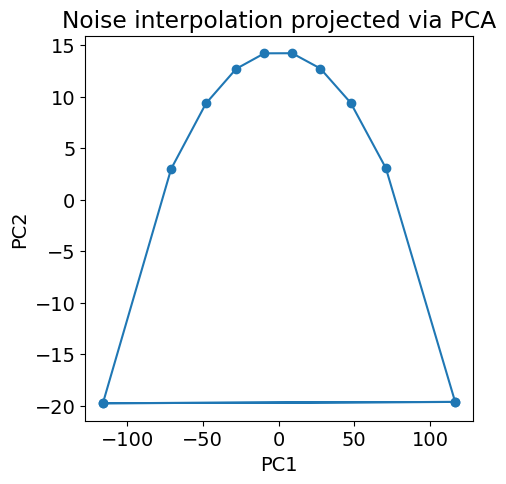

In [146]:
# select two noise vectors
z_a = base_batch["noise"][0]  # shape [1,1,2048,10]
z_b = base_batch["noise"][15]

# linear / spiral mixing coefficients
alphas = torch.linspace(0, 1, 10)

# prepare mixed noise
z_alphas = []
for a in alphas:
    a = a.view(1,1,1,1)  # make broadcastable
    z = torch.sqrt(1 - a) * z_a + torch.sqrt(a) * z_b
    z_alphas.append(z)

# flatten all noise vectors for PCA
all_z = torch.stack([z_a, z_b, *z_alphas]).flatten(1).numpy()  # shape [num_samples, d]

# fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(all_z)

# plot PCA projection
plt.figure(figsize=(5,5))
plt.plot(X_pca[:,0], X_pca[:,1], '-o')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Noise interpolation projected via PCA")
plt.show()

In [169]:
def latent_space_trajectory_heatmap(
    model,
    dataset,
    base_batch,
    z_a_idx=0,
    z_b_idx=20,
    feature_fn=None,
    pca=None,
    n_steps=10,
    device="cuda"
):
    """
    Interpolate between two latent noise vectors, project via PCA, 
    compute a feature on the model outputs, and plot a heatmap.
    
    Args:
        model: the transport model
        dataset: dataset object (for tensor_to_xarray)
        base_batch: dict containing base noise batch
        z_a_idx, z_b_idx: indices of noise vectors in batch to interpolate between
        feature_fn: function(ds) -> scalar feature
        pca: fitted PCA object
        n_steps: number of interpolation steps (including endpoints)
        device: device to run model on
    """
    # Extract noise vectors
    z_a = base_batch["noise"][z_a_idx].squeeze(1).to(device)
    z_b = base_batch["noise"][z_b_idx].squeeze(1).to(device)

    # Interpolate in sqrt-space
    alphas = torch.linspace(0, 1, n_steps)
    z_alphas = [torch.sqrt(1 - a) * z_a + torch.sqrt(a) * z_b for a in alphas]

    # Stack for PCA
    X = torch.stack([z_a, z_b, *z_alphas]).flatten(1).cpu().numpy()
    X_pca = pca.transform(X) if pca is not None else X

    # Compute feature values
    vals = []
    for z in [z_a, z_b, *z_alphas]:
        batch = {**base_batch}
        batch["noise"] = z.unsqueeze(1).to(device)
        with torch.no_grad():
            preds = model(batch)
        ds = dataset.tensor_to_xarray(preds["co2massmix"])
        vals.append(feature_fn(ds).item())

    # Plot
    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=vals, cmap="viridis", s=100)
    plt.plot(X_pca[:,0], X_pca[:,1], 'k--', alpha=0.5)
    plt.colorbar(label="Global mean CO₂")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title("Latent-space trajectory colored by CO₂ feature")
    plt.show()

    return X_pca, vals

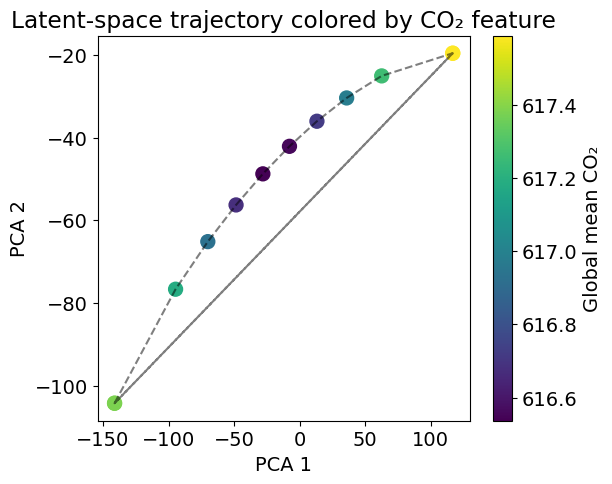

In [170]:
X_pca, vals = latent_space_trajectory_heatmap(
    model=transport_model,
    dataset=dataset,
    base_batch=base_batch,
    z_a_idx=0,
    z_b_idx=20,
    feature_fn=feature_fn_global_mean,
    pca=pca,
    n_steps=10,
    device="cuda"
)

In [167]:
def latent_space_heatmap(model, base_batch, dataset, z_a, z_b, feature_fn, pca, n_steps=10, device="cuda"):
    """
    Compute and plot a 2D heatmap of feature values over PCA-projected latent space.

    Args:
        model: The neural transport model.
        base_batch: Dictionary with the base batch data for model inputs.
        dataset: Dataset object with tensor_to_xarray method.
        z_a, z_b: Noise vectors to define interpolation space. Shape [N, C].
        feature_fn: Function(pred_ds) -> scalar (torch or float), e.g., global mean CO2.
        pca: Fitted PCA object (sklearn) to project latent vectors.
        n_steps: Number of interpolation steps along each axis (grid size = n_steps^2).
        device: "cuda" or "cpu".

    Returns:
        X_grid, Y_grid, vals_grid: 2D arrays for plotting heatmap.
    """
    alphas = torch.linspace(0, 1, n_steps)
    vals = np.zeros((n_steps, n_steps))
    grid_flat = []

    for i, a in enumerate(alphas):
        for j, b in enumerate(alphas):
            # bilinear sqrt-space interpolation
            z_interp = torch.sqrt(1 - a) * z_a + torch.sqrt(a) * (torch.sqrt(1 - b) * z_a + torch.sqrt(b) * z_b)
            
            # Evaluate feature
            batch = {**base_batch}
            batch["noise"] = z_interp.unsqueeze(0).to(device)  # add batch dim if needed
            with torch.no_grad():
                preds = model(batch)
            ds = dataset.tensor_to_xarray(preds["co2massmix"])
            vals[i, j] = feature_fn(ds).item()
            
            # Collect flattened latent vector for PCA
            grid_flat.append(z_interp.flatten().cpu().numpy())

    # PCA projection for visualization
    X_pca = pca.transform(np.stack(grid_flat))
    X_grid = X_pca[:, 0].reshape(n_steps, n_steps)
    Y_grid = X_pca[:, 1].reshape(n_steps, n_steps)
    vals_grid = vals

    # Plot heatmap
    plt.figure(figsize=(6,5))
    plt.pcolormesh(X_grid, Y_grid, vals_grid, shading='auto', cmap="viridis")
    plt.colorbar(label="Feature value")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title("Latent-space feature heatmap")
    plt.savefig("latent_space_heatmap.png", dpi=200)
    plt.show()
    
    return X_grid, Y_grid, vals_grid

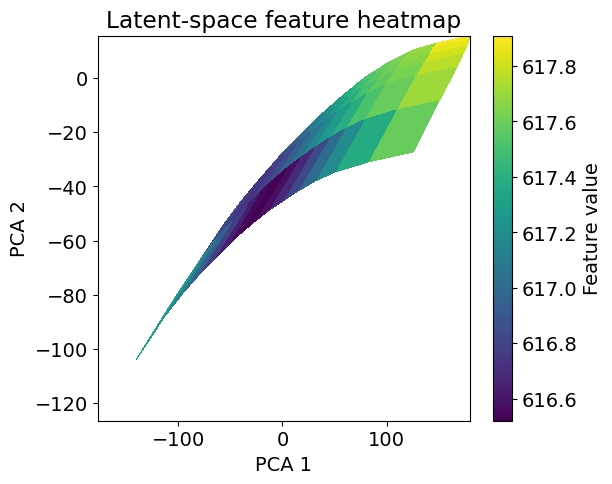

In [168]:
z_a = base_batch["noise"][0].squeeze(1)
z_b = base_batch["noise"][20].squeeze(1)

X_grid, Y_grid, vals_grid = latent_space_heatmap(
    model=transport_model,
    base_batch=base_batch,
    dataset=dataset,
    z_a=z_a,
    z_b=z_b,
    feature_fn=feature_fn_global_mean,
    pca=pca,
    n_steps=15,
    device="cuda"
)


In [173]:
def latent_space_mixing_analysis(
    model,
    dataset,
    base_batch,
    z_a,
    z_b,
    feature_fn,
    pca,
    alphas=None,
    device="cuda",
    save_outdir=None
):
    """
    Interpolate in latent noise space between z_a and z_b,
    compute model outputs, and visualize a PCA projection colored by a feature.

    Args:
        model: trained transport model
        dataset: dataset object with .tensor_to_xarray
        base_batch: dict containing a batch of data
        z_a, z_b: torch.Tensor noise vectors (already squeezed to [N, C])
        feature_fn: function to compute feature from model output (e.g., global mean CO₂)
        pca: fitted sklearn PCA object for dimensionality reduction
        alphas: torch.Tensor of interpolation coefficients (0 to 1)
        device: computation device ("cuda" or "cpu")
        save_outdir: optional folder to save intermediate outputs (not implemented here)
    
    Returns:
        results: dict containing 'X_pca', 'vals', 'alphas'
    """
    model.eval().to(device)
    if alphas is None:
        alphas = torch.linspace(0, 1, 10)
    
    # Interpolate in sqrt-space
    z_alphas = [torch.sqrt(1 - a) * z_a + torch.sqrt(a) * z_b for a in alphas]

    # PCA projection
    X_stack = torch.stack(z_alphas).flatten(1).cpu().numpy()
    X_pca = pca.transform(X_stack)

    # Compute feature values
    vals = []
    for z in z_alphas:
        batch = {k: (v.clone() if torch.is_tensor(v) else v) for k, v in base_batch.items()}
        batch["noise"] = z.unsqueeze(0).to(device)  # add batch dim
        with torch.no_grad():
            preds = model(batch)
        ds = dataset.tensor_to_xarray(preds["co2massmix"])
        vals.append(feature_fn(ds).item())

    # Plot heatmap
    plt.figure(figsize=(7, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=vals, cmap="viridis", s=100)
    plt.plot(X_pca[:, 0], X_pca[:, 1], 'k--', alpha=0.5)
    plt.colorbar(label="Feature value")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title("Latent-space trajectory colored by feature")
    plt.show()

    return {"X_pca": X_pca, "vals": np.array(vals), "alphas": alphas.cpu().numpy()}

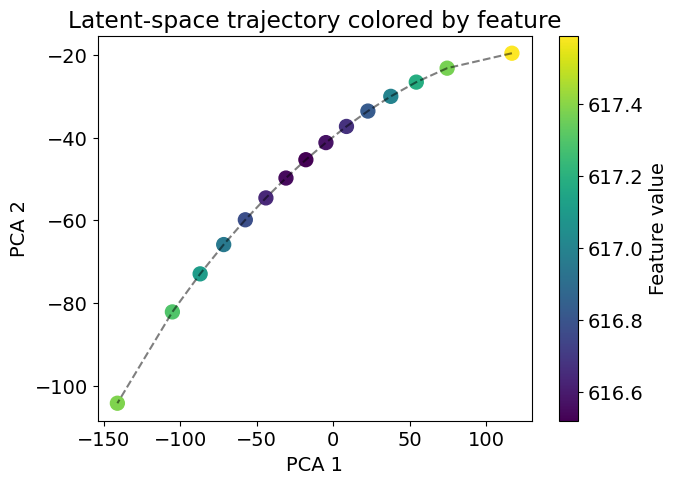

In [ ]:
results = latent_space_mixing_analysis(
    model=transport_model,
    dataset=dataset,
    base_batch=base_batch,
    z_a=base_batch["noise"][0].squeeze(1),
    z_b=base_batch["noise"][20].squeeze(1),
    feature_fn=feature_fn_global_mean,
    pca=pca,
    alphas=torch.linspace(0, 1, 15),
    device="cuda",
    save_outdir="latent_mixing_outputs"
)